In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("08-email_classification_svm.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [4]:
df["email_type"].unique()

array([0, 1], dtype=int64)

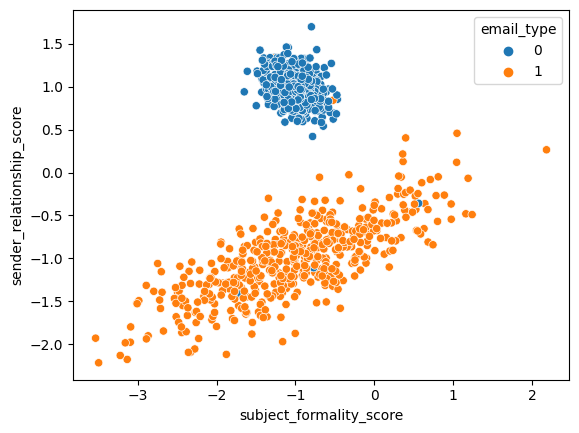

In [7]:
sns.scatterplot(x=df["subject_formality_score"], y=df["sender_relationship_score"], hue=df["email_type"])
plt.show()

In [8]:
x = df[["subject_formality_score", "sender_relationship_score"]].values
y = df["email_type"].values

In [9]:
y

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,

In [10]:
x

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]])

In [11]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
len(x_train), len(y_train), len(x_test), len(y_test)

(800, 800, 200, 200)

In [20]:
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

C:\Users\alica\AppData\Local\Temp\ipykernel_13308\3981076547.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)
C:\Users\alica\AppData\Local\Temp\ipykernel_13308\3981076547.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
C:\Users\alica\AppData\Local\Temp\ipykernel_13308\3981076547.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.float32)
C:\Users\alica\AppData\Local\Temp\i

In [21]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [22]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [23]:
x_train.ndim

2

In [24]:
y_train.ndim

2

In [25]:
from torch import nn

In [26]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
    
    def forward(self, x):
        return self.layer_2(self.layer_1(x))

In [27]:
model_0 = ClassificationModel()

In [28]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

c:\Users\alica\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_test)) * 100
    return accuracy

In [31]:
y_logits = model_0(x_test[:5])

In [33]:
y_pred_probs = torch.sigmoid(y_logits)

In [34]:
y_pred_probs

tensor([[0.6075],
        [0.7058],
        [0.6289],
        [0.6620],
        [0.6090]], grad_fn=<SigmoidBackward0>)

In [36]:
y_preds = torch.round(y_pred_probs)

In [37]:
y_preds

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)

In [38]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [39]:
calculate_accuracy(y_test=y_test[:5], y_pred=y_preds)

40.0

In [41]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
    model_0.train()
    
    y_logits = model_0(x_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train)
    accuracy = calculate_accuracy(y_test=y_train, y_pred=y_pred)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_logits = model_0(x_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits, y_test)
        test_accuracy = calculate_accuracy(y_test=y_test, y_pred=test_pred)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_accuracy:.2f}%")
    
    

Epoch: 0 | Loss: 0.67638 | Accuracy: 50.25% | Test Loss: 0.68193 | Test Accuracy: 48.00%
Epoch: 5 | Loss: 0.65908 | Accuracy: 50.25% | Test Loss: 0.66407 | Test Accuracy: 48.00%
Epoch: 10 | Loss: 0.64250 | Accuracy: 50.25% | Test Loss: 0.64695 | Test Accuracy: 48.00%
Epoch: 15 | Loss: 0.62658 | Accuracy: 50.25% | Test Loss: 0.63051 | Test Accuracy: 48.00%
Epoch: 20 | Loss: 0.61124 | Accuracy: 50.25% | Test Loss: 0.61467 | Test Accuracy: 48.00%
Epoch: 25 | Loss: 0.59644 | Accuracy: 50.38% | Test Loss: 0.59939 | Test Accuracy: 48.00%
Epoch: 30 | Loss: 0.58212 | Accuracy: 50.38% | Test Loss: 0.58460 | Test Accuracy: 48.00%
Epoch: 35 | Loss: 0.56825 | Accuracy: 51.50% | Test Loss: 0.57028 | Test Accuracy: 50.00%
Epoch: 40 | Loss: 0.55479 | Accuracy: 57.50% | Test Loss: 0.55637 | Test Accuracy: 56.50%
Epoch: 45 | Loss: 0.54171 | Accuracy: 68.00% | Test Loss: 0.54286 | Test Accuracy: 69.00%
Epoch: 50 | Loss: 0.52898 | Accuracy: 79.88% | Test Loss: 0.52972 | Test Accuracy: 79.50%
Epoch: 55 | 

In [42]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

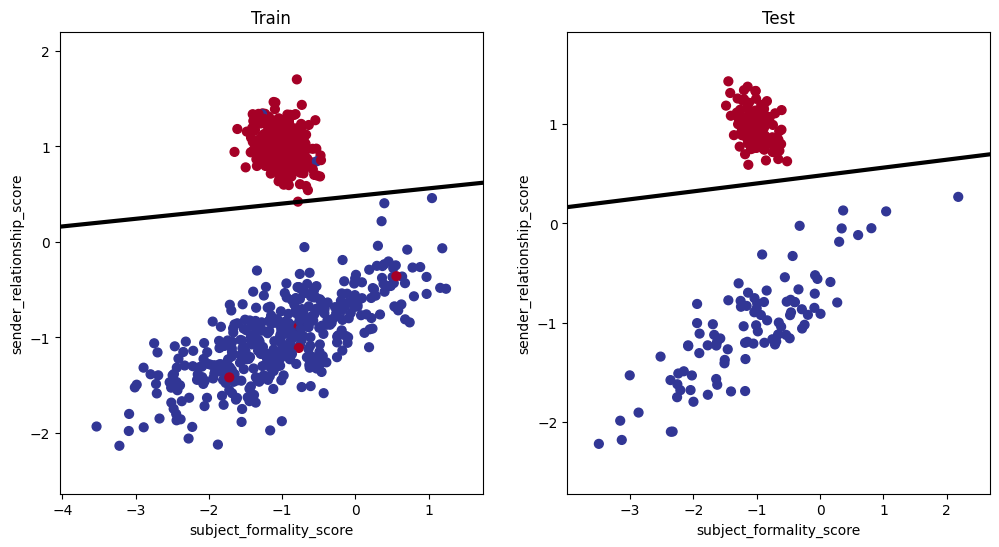

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, x_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, x_test, y_test)

plt.show()

In [44]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [45]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [47]:
df["seismic_event_detected"].unique()

array([0, 1], dtype=int64)

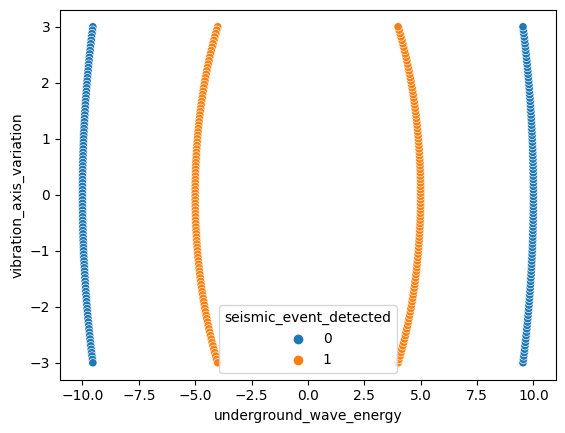

In [48]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])
plt.show()

In [49]:
x = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [50]:
x

array([[ 9.53939201, -3.        ],
       [ 9.55824059, -2.93939394],
       [ 9.57666854, -2.87878788],
       [ 9.59467828, -2.81818182],
       [ 9.61227215, -2.75757576],
       [ 9.62945245, -2.6969697 ],
       [ 9.64622137, -2.63636364],
       [ 9.66258107, -2.57575758],
       [ 9.67853361, -2.51515152],
       [ 9.69408101, -2.45454545],
       [ 9.70922521, -2.39393939],
       [ 9.7239681 , -2.33333333],
       [ 9.73831149, -2.27272727],
       [ 9.75225716, -2.21212121],
       [ 9.76580681, -2.15151515],
       [ 9.77896207, -2.09090909],
       [ 9.79172455, -2.03030303],
       [ 9.80409577, -1.96969697],
       [ 9.81607722, -1.90909091],
       [ 9.82767031, -1.84848485],
       [ 9.83887643, -1.78787879],
       [ 9.8496969 , -1.72727273],
       [ 9.86013297, -1.66666667],
       [ 9.87018588, -1.60606061],
       [ 9.87985679, -1.54545455],
       [ 9.88914683, -1.48484848],
       [ 9.89805706, -1.42424242],
       [ 9.90658851, -1.36363636],
       [ 9.91474216,

In [51]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [56]:
len(x_train), len(y_train), len(x_test), len(y_test)

(320, 320, 80, 80)

In [57]:
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [58]:
print(x_train.shape, y_train.shape)

torch.Size([320, 2]) torch.Size([320, 1])


In [59]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [60]:
x_train.ndim, y_train.ndim, x_test.ndim, y_test.ndim

(2, 2, 2, 2)

In [61]:
from torch import nn

In [98]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=16)
        self.layer_2 = nn.Linear(in_features=16, out_features=1)
        self.relu = nn.ReLU()

    
    def forward(self, x):
        return self.layer_2(self.relu(self.layer_1(x)))

In [99]:
model_1 = ClassificationModel()

In [100]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

In [101]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
    model_1.train()
    
    y_logits = model_1(x_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train)
    accuracy = calculate_accuracy(y_test=y_train, y_pred=y_pred)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()

    model_1.eval()

    with torch.inference_mode():
        test_logits = model_1(x_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits, y_test)
        test_accuracy = calculate_accuracy(y_test=y_test, y_pred=test_pred)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_accuracy:.2f}%")
    
    

Epoch: 0 | Loss: 0.85667 | Accuracy: 55.00% | Test Loss: 0.81991 | Test Accuracy: 57.50%
Epoch: 5 | Loss: 0.63512 | Accuracy: 56.25% | Test Loss: 0.57472 | Test Accuracy: 57.50%
Epoch: 10 | Loss: 0.62190 | Accuracy: 48.75% | Test Loss: 0.55979 | Test Accuracy: 55.00%
Epoch: 15 | Loss: 0.57717 | Accuracy: 54.37% | Test Loss: 0.53701 | Test Accuracy: 55.00%
Epoch: 20 | Loss: 0.53547 | Accuracy: 63.44% | Test Loss: 0.53557 | Test Accuracy: 63.75%
Epoch: 25 | Loss: 0.51222 | Accuracy: 82.81% | Test Loss: 0.52121 | Test Accuracy: 80.00%
Epoch: 30 | Loss: 0.47229 | Accuracy: 90.00% | Test Loss: 0.46448 | Test Accuracy: 90.00%
Epoch: 35 | Loss: 0.42743 | Accuracy: 88.44% | Test Loss: 0.40975 | Test Accuracy: 88.75%
Epoch: 40 | Loss: 0.38654 | Accuracy: 94.38% | Test Loss: 0.37772 | Test Accuracy: 97.50%
Epoch: 45 | Loss: 0.35085 | Accuracy: 99.38% | Test Loss: 0.34491 | Test Accuracy: 98.75%
Epoch: 50 | Loss: 0.31361 | Accuracy: 95.94% | Test Loss: 0.30349 | Test Accuracy: 95.00%
Epoch: 55 | 